<a href="https://colab.research.google.com/github/Suleymanov23/ecommerce-cohort-analysis/blob/main/cohort_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cohort Analysis - E-Commerce dataset

In this project I look at one year of online orders (October 2020 - September 2021) and study how customers behave over time using **cohort analysis**.

A cohort is just a group of customers who made their first purchase in the same month or week. With the cohorts it is possible to answer questions like:

- Are new customers coming back to buy again?
- How much money does each cohort bring in over its lifetime?
- How fast do we lose customers, and when does most of the drop-off happen?

The dataset (`sales.csv`) is a real-looking e-commerce order log with order details, product info, and customer info. I will only keep the columns that matter for cohort analysis and will not print any personal columns (names, emails, phone numbers, SSNs) in the outputs - there is no reason to expose that kind of data, so I treat it the same way I would treat real customer data.

Let's get into it.

## 1. Data Overview və Data Cleaning

### Task 1. Data Overview

First, the basic imports, then loading the file and taking a first look at it - shape, columns, data types, and a quick peek at the non-personal columns.

In [ ]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/sales.csv", low_memory=False)

print('Shape:', df.shape)
df.columns.tolist()

Shape: (286392, 33)


['order_id',
 'order_date',
 'status',
 'item_id',
 'sku',
 'qty_ordered',
 'price',
 'discount_amount',
 'category',
 'payment_method',
 'bi_st',
 'cust_id',
 'year',
 'month',
 'ref_num',
 'Name Prefix',
 'First Name',
 'Middle Initial',
 'Last Name',
 'Gender',
 'age',
 'full_name',
 'E Mail',
 'Customer Since',
 'SSN',
 'Phone No. ',
 'Place Name',
 'County',
 'City',
 'State',
 'Zip',
 'Region',
 'User Name']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286392 entries, 0 to 286391
Data columns (total 33 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_id         286392 non-null  object 
 1   order_date       286392 non-null  object 
 2   status           286392 non-null  object 
 3   item_id          286392 non-null  int64  
 4   sku              286392 non-null  object 
 5   qty_ordered      286392 non-null  int64  
 6   price            286392 non-null  float64
 7   discount_amount  286392 non-null  float64
 8   category         286392 non-null  object 
 9   payment_method   286392 non-null  object 
 10  bi_st            286392 non-null  object 
 11  cust_id          286392 non-null  int64  
 12  year             286392 non-null  int64  
 13  month            286392 non-null  object 
 14  ref_num          286392 non-null  int64  
 15  Name Prefix      286392 non-null  object 
 16  First Name       286392 non-null  obje

Only problematic column is `order_date`: it's currently stored as 'object', not as an date. I'll convert it to datetime in next step, since cohort analysis is impossible without real date objects (we need to group by month/week, subtract dates, etc.). Also some column names will be fixed (ex. cust_id to customer_id)

In [ ]:
# I'm only showing the columns that is needed for this analysis.
needed_cols = ['order_id','order_date','status','qty_ordered','price','discount_amount','category','payment_method','cust_id']
df[needed_cols].sample(5, random_state=1)

,order_id,order_date,status,qty_ordered,price,discount_amount,category,payment_method,cust_id
86222,100383262,20-12-2020,canceled,2,2739.6,370.0,Entertainment,easypay_voucher,67781
116591,100449785,05-03-2021,complete,2,999.9,100.0,Mobiles & Tablets,easypay_voucher,72869
270867,100540461,11-07-2021,canceled,2,79.6,0.0,Men's Fashion,bankalfalah,110669
236638,100503022,30-04-2021,received,6,50.0,0.0,Others,bankalfalah,101543
173199,100444620,12-02-2021,complete,2,64.8,0.0,Men's Fashion,cod,85086


The dataset has 286,392 rows and 33 columns, covering orders from **October 2020 to September 2021**, exactly 12 months, which is convenient for a monthly cohort. Only the 9 columns above are relevant to cohort analysis (order id, date, status, quantity, price, discount, category, payment method, customer id). Everything else is personal data and I'll drop in the next step

Also let's look how many distinct values `status` has

In [ ]:
df['status'].unique().tolist()

['received',
 'complete',
 'order_refunded',
 'canceled',
 'refund',
 'cod',
 'paid',
 'processing',
 'closed',
 'pending',
 'pending_paypal',
 'payment_review',
 'holded']

### Data Cleaning

Now let's keep only the columns we need, check for missing values and duplicates, and  decide what to do with the `status` column.

The dataset has a lot of different statuses:`received`,`complete`,`order_refunded`, `canceled`, `refund`, `cod`, `paid`,`processing`, `closed`, `pending`, `pending_paypal`, `payment_review`, `holded`. A cohort/revenue analysis should only count orders that the customer actually paid for and got. Cancelled orders and refunds never turned into real revenue, so counting them would make our numbers look bigger than their actual values.

In [ ]:
orders = df[needed_cols]
orders = orders.rename(columns={'cust_id': 'customer_id'})

print("Missing values per column:\n", orders.isna().sum())
print("\nDuplicate rows:", orders.duplicated().sum())

orders['status'].value_counts()

Missing values per column:
 order_id           0
order_date         0
status             0
qty_ordered        0
price              0
discount_amount    0
category           0
payment_method     0
customer_id        0
dtype: int64

Duplicate rows: 10692


,count
status,
canceled,112166
complete,88968
received,51775
order_refunded,25713
refund,3820
cod,2851
paid,756
closed,176
payment_review,57


There are 10692 duplicate rows, but most probably it is because we deleted the columns that proves they are different columns. Let's check duplicates in the previous table, if it is 0 duplicate it proves that they are products bought in the same order

In [ ]:
print("Duplicates in the first dataset:", df.duplicated().sum(0))

Duplicates in the first dataset: 0


In [ ]:
# I decided to keep only orders that effects the revenue, so they are succesfull purchase
# 'complete' / 'received' - successfull purchase.
# 'paid' -> payment went through.
# 'cod' (cash on delivery, still open but a genuine order) - keep too.
# I drop everthing else

succesfull = ['complete', 'received', 'paid', 'cod']
orders = orders[orders['status'].isin(succesfull)]

orders['order_date'] = pd.to_datetime(orders['order_date'], format='%d-%m-%Y')

print(round(df[df['status']=='canceled'].status.count() / df.status.count() * 100, 1), '% of orders is canceled orders')
print("Rows after cleaning:", orders.shape[0], "out of", df.shape[0], "original rows")
print(round(orders.shape[0] / df.shape[0] * 100, 1), "% of all rows kept")
orders.head()

39.2 % of orders is canceled orders
Rows after cleaning: 144350 out of 286392 original rows
50.4 % of all rows kept


,order_id,order_date,status,qty_ordered,price,discount_amount,category,payment_method,customer_id
0,100354678,2020-10-01,received,21,89.9,0.0,Men's Fashion,cod,60124
1,100354678,2020-10-01,received,11,19.0,0.0,Men's Fashion,cod,60124
2,100354680,2020-10-01,complete,9,149.9,0.0,Men's Fashion,cod,60124
3,100354680,2020-10-01,complete,9,79.9,0.0,Men's Fashion,cod,60124
4,100367357,2020-11-13,received,2,99.9,0.0,Men's Fashion,cod,60124


There were no missing values and no duplicate rows in the data.`status` filter, though, removed a lot: only 144,350 rows (50.4%) count as real purchases. Canceled orders alone are 39% of the whole dataset. I'd flag the cancellation rate as its own separate problem worth investigating, completely apart from the cohort analysis.

### Revenue

Now I create a `revenue` column for every order line, using quantity, price, and discount.

In [ ]:
orders['revenue'] = orders['qty_ordered'] * orders['price'] - orders['discount_amount']

print(orders['revenue'].describe())
print("\nNegative revenue rows:", (orders['revenue'] < 0).sum())
print("Zero revenue rows:", (orders['revenue'] == 0).sum(), f"({round((orders['revenue']==0).mean()*100,2)}% of rows)")

count    144350.000000
mean       1191.604240
std        2310.453407
min           0.000000
25%          99.800000
50%         240.315000
75%        1358.600000
max       46679.600000
Name: revenue, dtype: float64

Negative revenue rows: 0
Zero revenue rows: 625 (0.43% of rows)


No negative revenue, which is good, it means discounts never exceed the order value. There are 625 rows with 0 revenue (about 0.43%). That's not many, so I'm leaving them in, they just won't add anything to the revenue totals.

## 2. Monthly Cohort Analysis

### First Order Date

For every customer, I find the date of their first order and attach it back to the main `orders` table. This date shows their cohort.

In [ ]:
first_order_date = orders.groupby('customer_id')['order_date'].min()
first_order_date.name = 'first_order_date'

orders = orders.join(first_order_date, on='customer_id')
orders[['customer_id', 'order_date', 'first_order_date']].sample(5, random_state=1)

,customer_id,order_date,first_order_date
273584,111416,2021-07-24,2021-07-24
91833,68535,2020-12-20,2020-12-20
86335,37215,2020-12-20,2020-12-20
31722,12800,2020-12-20,2020-11-17
152760,80431,2021-05-18,2020-12-29


Join function takes only the first order date to every row that costumer has, not matter how many order they have later.

### Monthly Periods

Now let's turn the exact dates into months, both for the first order (which cohort a customer belongs to) and for every individual order (when that revenue actually happened).

In [ ]:
orders['first_order_month'] = orders['first_order_date'].dt.to_period('M')
orders['order_month'] = orders['order_date'].dt.to_period('M')

n_cohorts = orders['first_order_month'].nunique()
print("Number of monthly cohorts:", n_cohorts)
sorted(orders['first_order_month'].astype(str).unique())

Number of monthly cohorts: 12


['2020-10',
 '2020-11',
 '2020-12',
 '2021-01',
 '2021-02',
 '2021-03',
 '2021-04',
 '2021-05',
 '2021-06',
 '2021-07',
 '2021-08',
 '2021-09']

There are **12 monthly cohorts**, one for every month in the dataset, so every month had at least one new customer.

### Cohort Summary

For each monthly cohort, let's look at the total number of unique orders, unique customers, and total revenue it gived (across its whole lifetime)

In [ ]:
cohort_summary = orders.groupby('first_order_month').agg(uni_num_order=('order_id', 'nunique'),
uni_num_customer=('customer_id', 'nunique'),
total_revenue=('revenue', 'sum')).reset_index().sort_values('first_order_month')

cohort_summary['total_revenue'] = cohort_summary['total_revenue'].round(0)
cohort_summary

,first_order_month,uni_num_order,uni_num_customer,total_revenue
0,2020-10,7915,1861,11933045.0
1,2020-11,8247,2555,13060748.0
2,2020-12,35260,14129,73512356.0
3,2021-01,4108,2361,3738116.0
4,2021-02,3273,1407,2490355.0
5,2021-03,8369,4174,20500989.0
6,2021-04,12141,6986,22243833.0
7,2021-05,3271,2306,3184658.0
8,2021-06,5756,2847,12734489.0
9,2021-07,2145,1435,4499304.0


December 2020 is a massive outlier, so there is 14,129 new customers and about 73.5 million total revenue.It can be because of new year sales. This single month is going to dominate a lot of the charts below, so I'll call it out again when we get there instead of pretending it's a normal data point.

### Cohort Summary Visualization

Let's plot orders, customers, and revenue per cohort month, so the December spike (and the overall shape of the year) is easy to see at a glance.

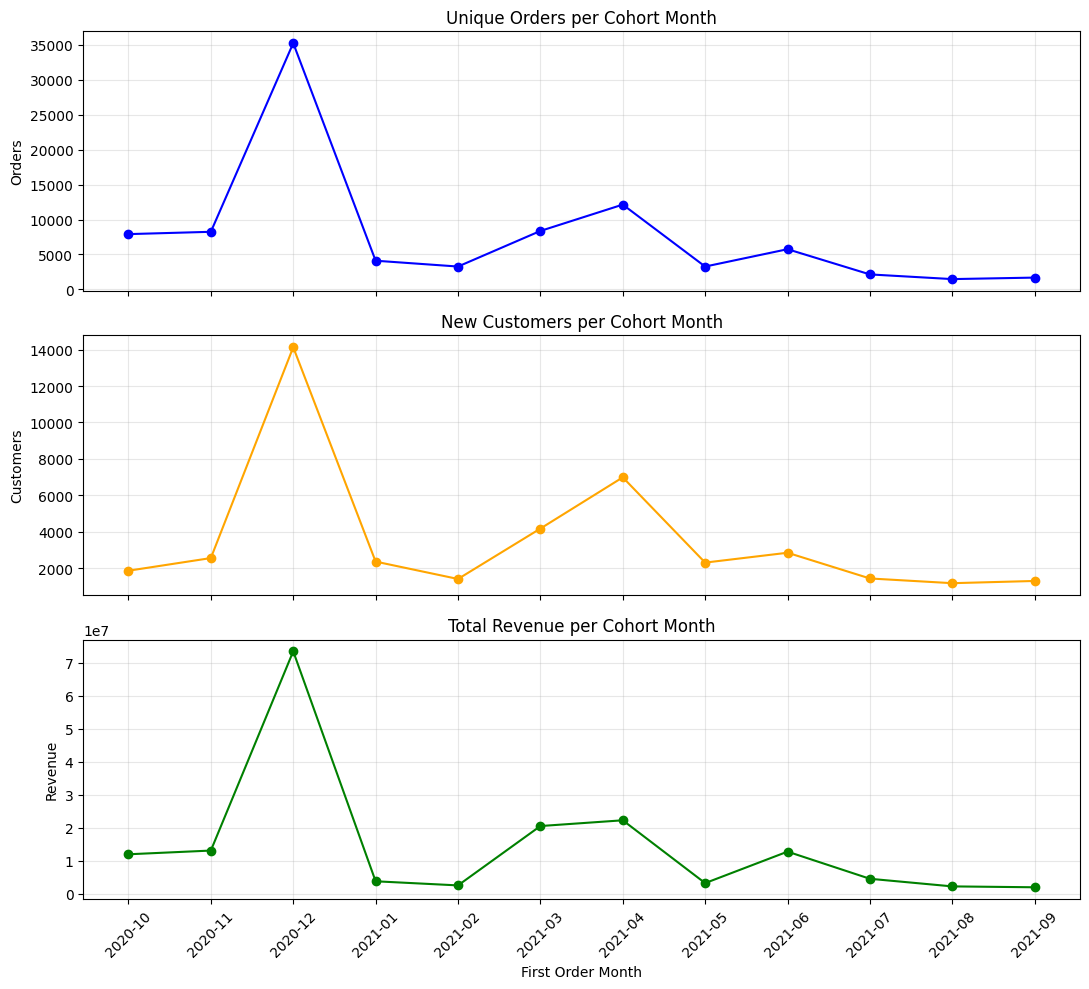

In [ ]:
cohort_summary_plot = cohort_summary.copy()
cohort_summary_plot['first_order_month'] = cohort_summary_plot['first_order_month'].astype(str)

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

axes[0].plot(cohort_summary_plot['first_order_month'], cohort_summary_plot['uni_num_order'], marker='o', color='blue')
axes[0].set_title('Unique Orders per Cohort Month')
axes[0].set_ylabel('Orders')

axes[1].plot(cohort_summary_plot['first_order_month'], cohort_summary_plot['uni_num_customer'], marker='o', color='orange')
axes[1].set_title('New Customers per Cohort Month')
axes[1].set_ylabel('Customers')

axes[2].plot(cohort_summary_plot['first_order_month'], cohort_summary_plot['total_revenue'], marker='o', color='green')
axes[2].set_title('Total Revenue per Cohort Month')
axes[2].set_ylabel('Revenue')
axes[2].set_xlabel('First Order Month')

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

All three lines move together and all three spike significantly in December 2020, then drop back down in January and stay in a lower, "normal" range for most of the rest of the year, with a smaller second bump in April 2021 (worth checking, maybe a spring sale). This tells me the this system relies a lot on big promotional moments rather than steady organic growth, good to know before we even look at retention.

### Customer Activity Pivot Table

Now a pivot table: rows are the cohort (first order month), columns are the order month, and values are how many unique customers from that cohort were active in that month

In [ ]:
activity_pivot = orders.pivot_table(index='first_order_month',columns='order_month',values='customer_id',aggfunc='nunique')
activity_pivot

order_month,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09
first_order_month,,,,,,,,,,,,
2020-10,1861.0,313.0,387.0,170.0,123.0,176.0,151.0,89.0,142.0,85.0,54.0,94.0
2020-11,NaN,2555.0,578.0,219.0,140.0,206.0,183.0,109.0,191.0,85.0,48.0,92.0
2020-12,NaN,NaN,14129.0,1021.0,459.0,632.0,681.0,329.0,562.0,262.0,170.0,270.0
2021-01,NaN,NaN,NaN,2361.0,158.0,110.0,111.0,69.0,77.0,63.0,42.0,53.0
2021-02,NaN,NaN,NaN,NaN,1407.0,122.0,95.0,54.0,55.0,33.0,27.0,30.0
2021-03,NaN,NaN,NaN,NaN,NaN,4174.0,524.0,131.0,233.0,83.0,49.0,83.0
2021-04,NaN,NaN,NaN,NaN,NaN,NaN,6986.0,258.0,264.0,95.0,63.0,78.0
2021-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2306.0,161.0,89.0,49.0,45.0
2021-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2847.0,145.0,66.0,101.0


Across any row, the numbers fall off a cliff after month 0, for example, the December 2020 cohort starts at 14,129 customers and only 1,021 of them come back in January 2021. In every cohort this happens, which is a strong early signal that repeat purchase is a real problem for this store, not just a December.

### Monthly Cohort Metrics

Letəs group by both the cohort month and the order month together, and calculate total revenue and unique customers for each combination. This is the table we'll build ARPU

In [ ]:
cohort_metrics = orders.groupby(['first_order_month', 'order_month']).agg(total_revenue=('revenue', 'sum'),uni_num_customer=('customer_id', 'nunique')).reset_index()
cohort_metrics.head(10)

,first_order_month,order_month,total_revenue,uni_num_customer
0,2020-10,2020-10,2.291765e+06,1861
1,2020-10,2020-11,9.983831e+05,313
2,2020-10,2020-12,3.683963e+06,387
3,2020-10,2021-01,4.117483e+05,170
4,2020-10,2021-02,2.908642e+05,123
5,2020-10,2021-03,1.549576e+06,176
6,2020-10,2021-04,1.215422e+06,151
7,2020-10,2021-05,2.152874e+05,89
8,2020-10,2021-06,6.074878e+05,142
9,2020-10,2021-07,1.890899e+05,85


This is the "long" version of the pivot table above, one row per cohort/month. It's more useful for calculations, which is exactly why the next steps turn it into pivot tables.

### ARPU

**ARPU** (Average Revenue Per User) shows how much averagely one active customer spends in a given month. I calculate it as `total_revenue / uni_num_customer` for every cohort/month pair


In [ ]:
cohort_metrics['ARPU'] = cohort_metrics['total_revenue'] / cohort_metrics['uni_num_customer']

arpu_pivot = cohort_metrics.pivot_table(index='first_order_month',columns='order_month',values='ARPU')
arpu_pivot.round(1)

order_month,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09
first_order_month,,,,,,,,,,,,
2020-10,1231.5,3189.7,9519.3,2422.0,2364.7,8804.4,8049.2,2419.0,4278.1,2224.6,1720.7,4112.1
2020-11,NaN,1781.1,6330.6,2042.7,2337.0,6576.5,5735.3,2219.0,4184.4,2488.7,1598.5,3726.7
2020-12,NaN,NaN,4057.4,1319.4,2019.2,8173.5,6392.1,1754.8,4486.8,1374.2,1154.0,2729.6
2021-01,NaN,NaN,NaN,1100.6,1068.7,1689.9,2264.6,1936.8,1745.1,2634.0,1071.1,1028.3
2021-02,NaN,NaN,NaN,NaN,962.6,2992.3,2439.3,2354.0,3401.0,2714.3,2015.8,2700.5
2021-03,NaN,NaN,NaN,NaN,NaN,3563.8,6105.4,2588.4,6169.8,2135.1,1140.3,5018.9
2021-04,NaN,NaN,NaN,NaN,NaN,NaN,2820.5,1337.7,5949.4,1638.8,1495.4,4792.7
2021-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1043.4,3051.3,1777.8,1178.9,1585.9
2021-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3793.4,5654.6,9294.0,4963.4


ARPU actually goes up for most cohorts after month 0. It's not that customers are spending more per person, it's that only the most engaged, highest-spending customers are the ones still buying in later months, so the company depends on them. So high later-month ARPU here is really a symptom of low retention, not a sign of growing loyalty.

### Monthly Cohort Lifetime

To compare cohorts fairly (a December cohort and a March cohort have different calendar months but the same idea of "month 0, month 1, month 2 so on"), I calculate `cohort_lifetime`: how many months after the first purchase each order happened. Month 0 = the first purchase month itself.

In [ ]:
def get_lifetime_in_months(row):
    months_diff = (row['order_month'].year - row['first_order_month'].year) * 12 + (row['order_month'].month - row['first_order_month'].month)
    return months_diff

cohort_metrics['cohort_lifetime'] = cohort_metrics.apply(get_lifetime_in_months, axis=1)
cohort_metrics.sort_values('cohort_lifetime', ascending=False).head()

,first_order_month,order_month,total_revenue,uni_num_customer,ARPU,cohort_lifetime
11,2020-10,2021-09,386539.697,94,4112.124436,11
10,2020-10,2021-08,92918.063,54,1720.704870,10
22,2020-11,2021-09,342858.502,92,3726.722848,10
9,2020-10,2021-07,189089.925,85,2224.587353,9
21,2020-11,2021-08,76727.263,48,1598.484646,9


 The oldest cohort (October 2020) has a lifetime of up to 11 months in this datasetç that's the maximum possible, since the data ends in September 2021. Newer cohorts naturally have fewer lifetime months available, which is why the pivot tables below get more triangular (more empty cells) toward foot.

### ARPU Heatmap

Same ARPU numbers as before, but now indexed by `cohort_lifetime` instead of calendar month  in a heatmap

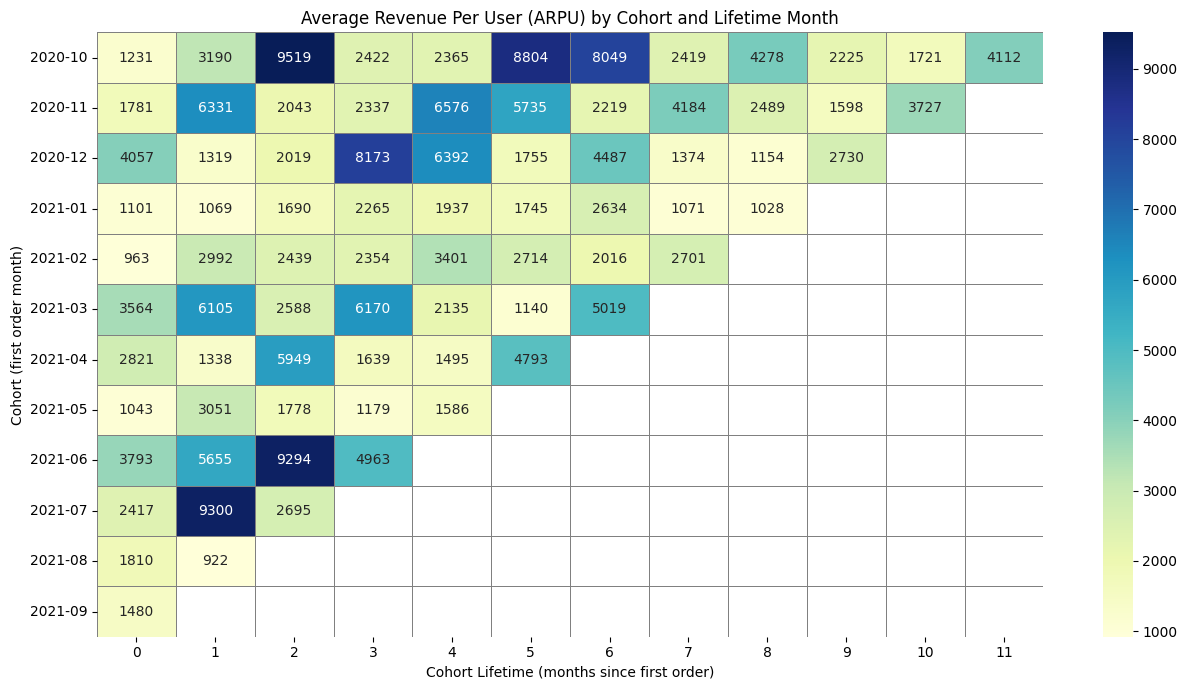

In [ ]:
arpu_lifetime_pivot = cohort_metrics.pivot_table(index='first_order_month', columns='cohort_lifetime',values='ARPU')
arpu_lifetime_pivot.index = arpu_lifetime_pivot.index.astype(str)

plt.figure(figsize=(13, 7))
plt.title('Average Revenue Per User (ARPU) by Cohort and Lifetime Month')
sns.heatmap(arpu_lifetime_pivot, annot=True, fmt='.0f', linewidths=0.5,linecolor='gray', cmap='YlGnBu')
plt.xlabel('Cohort Lifetime (months since first order)')
plt.ylabel('Cohort (first order month)')
plt.tight_layout()
plt.show()

 Month 0 (the leftest column) is consistently the lowest or one of the lowest ARPU values for almost every cohortç customers spend less on their very first order than they do later, on average. Column 1 and beyond are noisy (lots of ups and downs), which fits with what we already noticedçthose later columns are based on very few surviving customers, so a single big spender can swing the whole column. If I had more data, I'd want to see the customer count next to every ARPU cell to know how much to trust each numberç right now a 9,500 ARPU with 5 customers and a 1,200 ARPU with 500 customers are shown with equal visual weight, which is a bit misleading

## 3. Weekly Retention Analysis

Monthly cohorts are good for a big-picture view, but weekly cohorts will be more precise and we will not wait a month to se how business results change


### Weekly Periods

For every order I find the Monday that starts its week (`buy_week`), and for every customer the Monday that starts the week of their first order (`first_buy_week`)

In [ ]:
orders['buy_week'] =(orders['order_date'] - pd.to_timedelta(orders['order_date'].dt.weekday, unit='D')).dt.normalize()
orders['first_buy_week'] = (orders['first_order_date'] - pd.to_timedelta(orders['first_order_date'].dt.weekday, unit='D')).dt.normalize()

orders[['order_date', 'buy_week', 'first_order_date', 'first_buy_week']].sample(5, random_state=2)

,order_date,buy_week,first_order_date,first_buy_week
106611,2020-12-21,2020-12-21,2020-12-21,2020-12-21
157561,2020-12-31,2020-12-28,2020-12-31,2020-12-28
280933,2021-09-10,2021-09-06,2021-09-10,2021-09-06
97389,2020-12-20,2020-12-14,2020-12-20,2020-12-14
66119,2020-12-24,2020-12-21,2020-12-06,2020-11-30


 Subtracting `dt.weekday` (0 = Monday, 6 = Sunday) from a date always rounds it down to the Monday of that same week. So every order, no matter which day of the week it happened, gets grouped into a clean weekly bucket, which is what we need for weekly cohorts.

###  Weekly Cohort Lifetime

Same idea as the monthly lifetime, just in weeks now: how many weeks after their first purchase week did each order happen?

In [ ]:
orders['cohort_lifetime_w'] = ((orders['buy_week'] - orders['first_buy_week']) / np.timedelta64(1, 'W')).astype(int)

orders[['first_buy_week', 'buy_week', 'cohort_lifetime_w']].sample(5, random_state=3)

,first_buy_week,buy_week,cohort_lifetime_w
74860,2020-12-14,2020-12-21,1
11165,2020-10-05,2020-10-05,0
280854,2021-08-23,2021-09-13,3
177483,2021-02-22,2021-06-28,18
139277,2020-12-21,2020-12-21,0


`cohort_lifetime_w = 0` means "the same week as the first purchase," `1` means "one week later," and so on.Much finer-grained view than the monthly version, which is the whole point of doing it weekly.

### Weekly Active Customers

Grouping by first purchase week and weekly lifetime, let's count how many unique customers were active in each combination.

In [ ]:
weekly_cohorts = orders.groupby(['first_buy_week', 'cohort_lifetime_w']).agg(active_customers=('customer_id', 'nunique')).reset_index()

print("Number of weekly cohorts:", orders['first_buy_week'].nunique())
weekly_cohorts.head(10)

Number of weekly cohorts: 53


,first_buy_week,cohort_lifetime_w,active_customers
0,2020-09-28,0,402
1,2020-09-28,1,26
2,2020-09-28,2,27
3,2020-09-28,3,24
4,2020-09-28,4,14
5,2020-09-28,5,21
6,2020-09-28,6,32
7,2020-09-28,7,27
8,2020-09-28,8,20
9,2020-09-28,9,16


 There is 53 separate groups, which lets us catch fast changes (like "did that one campaign in week 14 actually bring people back?") that a monthly view would completely blur together.

### Initial Cohort Size

For every weekly cohort we need its starting size, the number of customers active in week 0 (their first purchase week). I calculate this and attach it back to every row of that cohort.


In [ ]:
cohort_week0_size = weekly_cohorts[weekly_cohorts['cohort_lifetime_w'] == 0][['first_buy_week', 'active_customers']].rename(columns={'active_customers': 'first_week_customers'})

weekly_cohorts = weekly_cohorts.merge(cohort_week0_size, on='first_buy_week')
weekly_cohorts.head()

,first_buy_week,cohort_lifetime_w,active_customers,first_week_customers
0,2020-09-28,0,402,402
1,2020-09-28,1,26,402
2,2020-09-28,2,27,402
3,2020-09-28,3,24,402
4,2020-09-28,4,14,402


I used `merge()` here instead of `join()`, `merge()` matches on a shared olumn (`first_buy_week`) on both sides, while `join()` matches a column against the other table's index. Since `cohort_week0_size` doesn't have `first_buy_week` as its index, i used merge

### Retention Rate

Now the actual retention rate: for each cohort and each lifetime week, divide the active customers that week by the cohort's starting size (week 0).

In [ ]:
weekly_cohorts['retention'] =  weekly_cohorts['active_customers'] / weekly_cohorts['first_week_customers']

weekly_cohorts.head(10)

,first_buy_week,cohort_lifetime_w,active_customers,first_week_customers,retention
0,2020-09-28,0,402,402,1.000000
1,2020-09-28,1,26,402,0.064677
2,2020-09-28,2,27,402,0.067164
3,2020-09-28,3,24,402,0.059701
4,2020-09-28,4,14,402,0.034826
5,2020-09-28,5,21,402,0.052239
6,2020-09-28,6,32,402,0.079602
7,2020-09-28,7,27,402,0.067164
8,2020-09-28,8,20,402,0.049751
9,2020-09-28,9,16,402,0.039801


Week 0 will always show 100% retention, every cohort starts "fully retained" on the week it's created. The interesting numbers start from week 1

### Retention Matrix and Heatmap

Let's turn retention into a pivot table (cohort × lifetime week) and visualize it as a percentage heatmap.

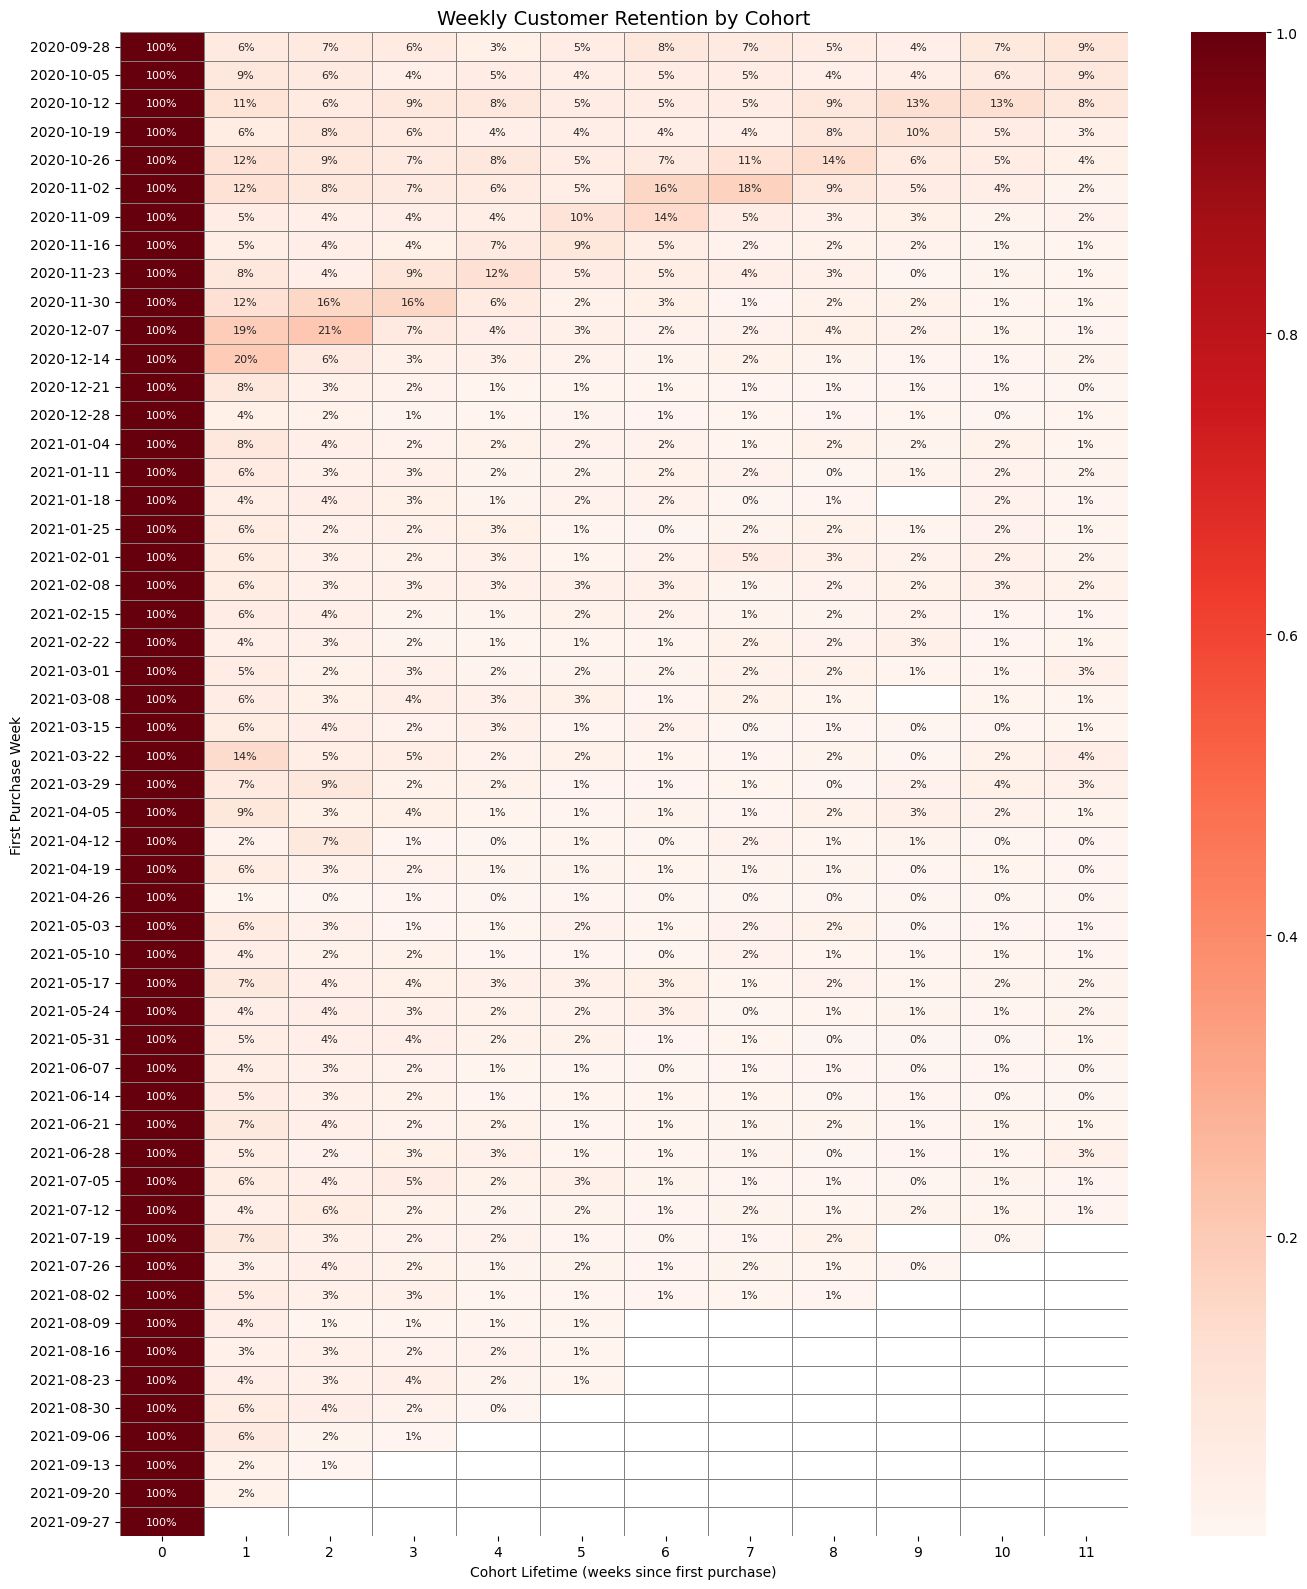

In [ ]:
retention_pivot = weekly_cohorts.pivot_table(index='first_buy_week', columns='cohort_lifetime_w', values='retention')
retention_pivot.index = retention_pivot.index.strftime('%Y-%m-%d')

# limiting to the first 12 weeks keeps the heatmap readable
# almost nothing interesting survives past that point anyway (see insight below)
retention_view = retention_pivot.iloc[:, :12]

plt.figure(figsize=(14, 16))
plt.title('Weekly Customer Retention by Cohort', fontsize=14)
sns.heatmap(retention_view, annot=True, fmt='.0%', linewidths=0.5, linecolor='gray', cmap='Reds', annot_kws={"size": 8})
plt.xlabel('Cohort Lifetime (weeks since first purchase)')
plt.ylabel('First Purchase Week')
plt.tight_layout()
plt.show()

In [ ]:
avg_retention = retention_pivot.mean(axis=0)
print("Average retention by lifetime week (all cohorts combined):")
print((avg_retention.iloc[:9] * 100).round(1).astype(str) + '%')

Average retention by lifetime week (all cohorts combined):
cohort_lifetime_w
0    100.0%
1      6.5%
2      4.5%
3      3.4%
4      2.7%
5      2.3%
6      2.6%
7      2.4%
8      2.3%
dtype: object


 This is the most important chart in the whole project. On average, retention crashes from 100% in week 0 to about 6.5% in week 1 meaning approximately 93 out of every 100 first-time customers never come back the following week. It keeps sliding slowly after that, settling around 2-3% by week 6-8. There's no cohort that holds onto customers noticeably better than the others. The drop is steep and consistent across almost every week in the dataset. In plain terms, this business is very good at getting a *first* order out of someone, but has almost no repeat-purchase system.

 I would invest this business the most money for whatever happens 7 days after a customer's fist order (a follow-up email, a discount on the second purchase, better product experienc, quick order suggestions basedd on previous orders) because that's where nearly all the loss happens.

### Churn Rate

Churn is the flip side of retention: instead of comparing to week 0, we compare each week to the **previous** week, using `pct_change()`. A cumulative churn view (`1 - retention` against week 0) is also easy to get from what we alreafy built.

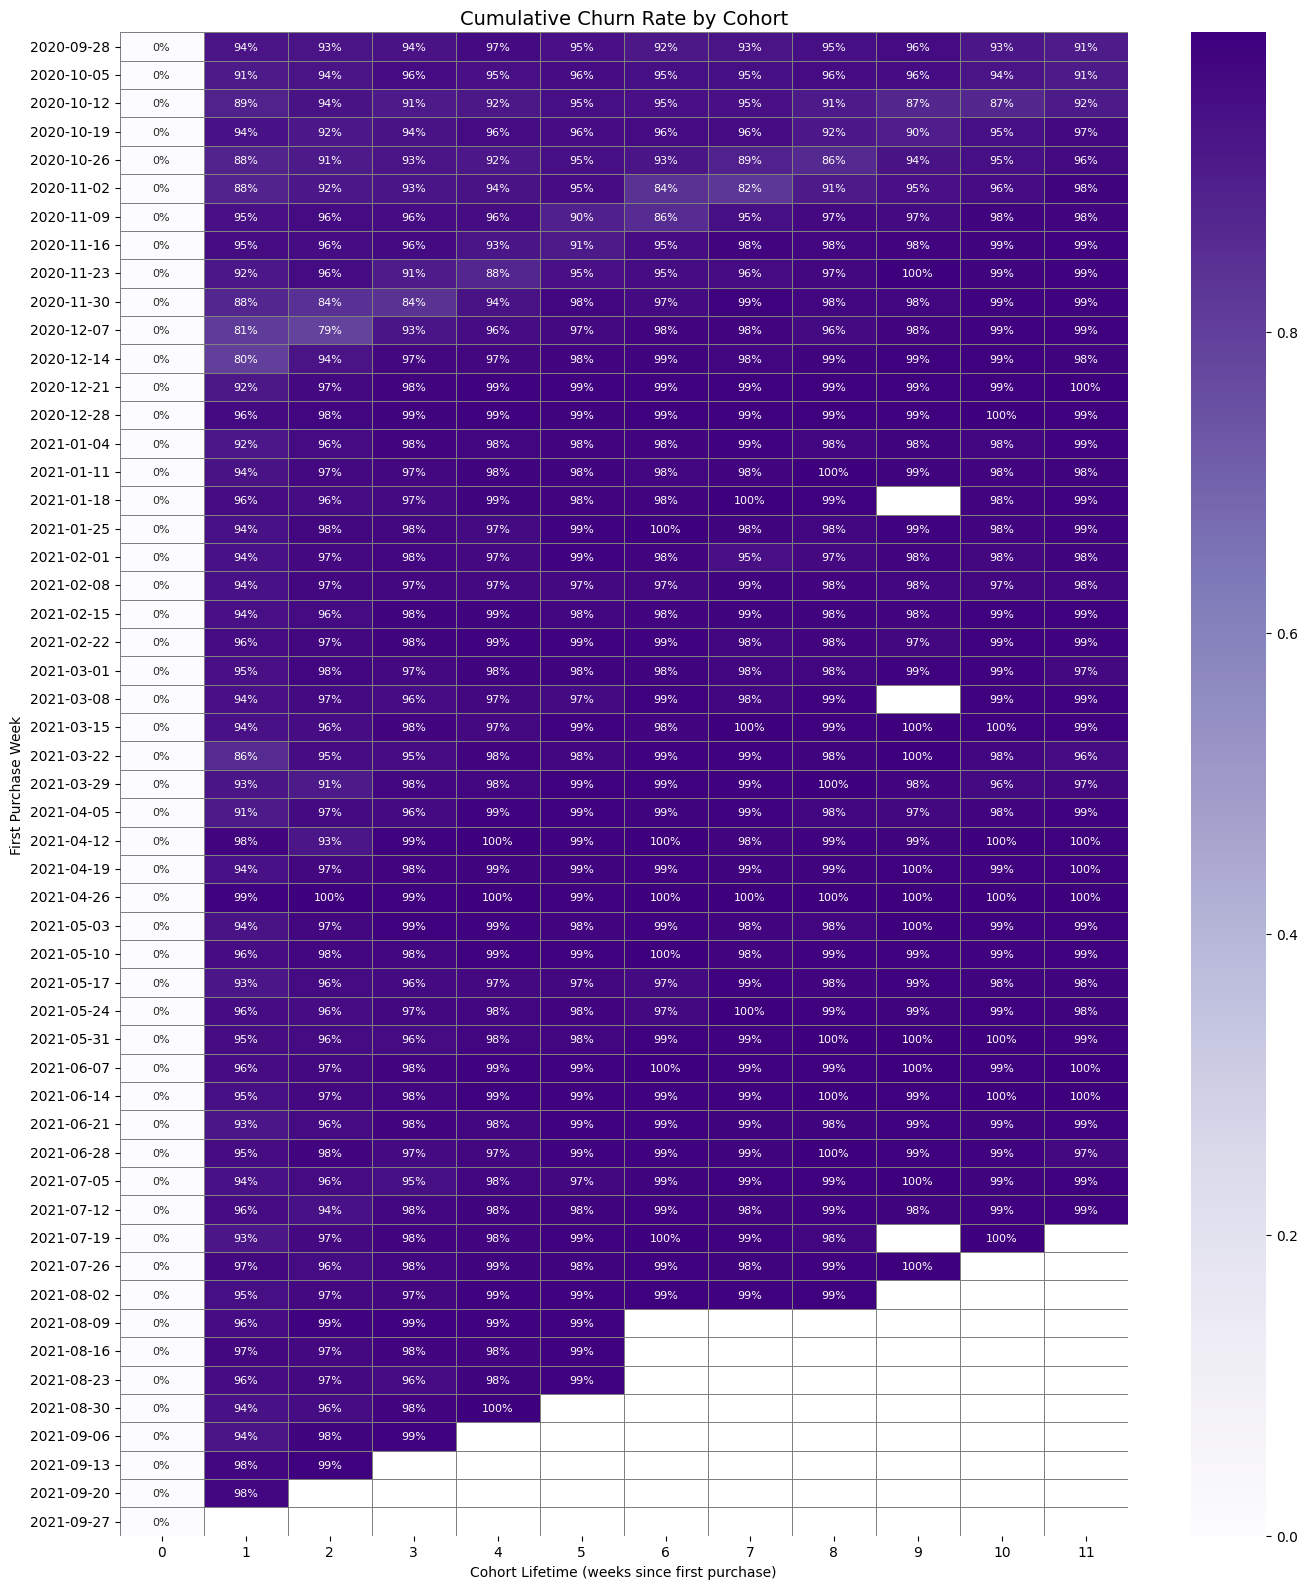

In [ ]:
weekly_cohorts['churn_rate_wow'] = weekly_cohorts.groupby('first_buy_week')['active_customers'].pct_change() * -1
weekly_cohorts['cumulative_churn'] = 1 - weekly_cohorts['retention']

churn_pivot = weekly_cohorts.pivot_table(index='first_buy_week', columns='cohort_lifetime_w', values='cumulative_churn')
churn_pivot.index = churn_pivot.index.strftime('%Y-%m-%d')
churn_view = churn_pivot.iloc[:, :12]

plt.figure(figsize=(14, 16))
plt.title('Cumulative Churn Rate by Cohort', fontsize=14)
sns.heatmap(churn_view, annot=True, fmt='.0%', linewidths=0.5, linecolor='gray', cmap='Purples', annot_kws={"size": 8})
plt.xlabel('Cohort Lifetime (weeks since first purchase)')
plt.ylabel('First Purchase Week')
plt.tight_layout()
plt.show()

`cumulative_churn = 1 - retention`, so it's basically the retention heatmap flipped upside down, instead of "how many stayed," it directly answers "how many did we lose since the star. By week 3-4, cumulative churn is already sitting above 95% for almost every cohortç the business is essentially losing nearly everyone within the first month, not gradually over the year.

Does the December spike also mean worse retention (since it includes rushed/promo shoppers), or is it about the same as other months?

In [ ]:
is_december = retention_pivot.index.astype(str).str.startswith('2020-12')

if '2020-12-07' in retention_pivot.index:
    dec_retention = retention_pivot.loc['2020-12-07':'2020-12-28'].mean()
else:
    dec_retention = None
other_weeks = retention_pivot[~is_december]

dec_mask = weekly_cohorts['first_buy_week'].dt.strftime('%Y-%m') == '2020-12'
w1_mask = weekly_cohorts['cohort_lifetime_w'] == 1

dec_week1 = weekly_cohorts[dec_mask & w1_mask]['retention'].mean()
non_dec_week1 = weekly_cohorts[~dec_mask & w1_mask]['retention'].mean()

print(f"Week-1 retention, December cohorts: {dec_week1*100:.1f}%")
print(f"Week-1 retention, all other cohorts: {non_dec_week1*100:.1f}%")

Week-1 retention, December cohorts: 12.6%
Week-1 retention, all other cohorts: 6.0%


December's week1 retention is close to (sometimes even a bit below) the retention of other months, so the huge December volume isn't hiding a secretly loyal group of shoppers, the people who came in during the big sale churn at basically the same brutal rate as everyone else. That's actually useful to know: it means fixing retention is a general product/lifecycle problem, not something specific to sale shoppers vs. regular shoppers.

Which product categories bring in the most first-purchase revenue, and does that match where the repeat purchases come from?

In [ ]:
first_purchases = orders[orders['order_month'] == orders['first_order_month']]
repeat_purchases = orders[orders['order_month'] != orders['first_order_month']]

cat_first = first_purchases.groupby('category')['revenue'].sum().sort_values(ascending=False)
cat_repeat = repeat_purchases.groupby('category')['revenue'].sum().sort_values(ascending=False)

compare_cat = pd.DataFrame({'first_purchase_revenue': cat_first,'repeat_purchase_revenue': cat_repeat}).fillna(0)
compare_cat['repeat_share_%'] = (compare_cat['repeat_purchase_revenue'] / (compare_cat['first_purchase_revenue'] + compare_cat['repeat_purchase_revenue']) * 100).round(1)
compare_cat.sort_values('first_purchase_revenue', ascending=False)

,first_purchase_revenue,repeat_purchase_revenue,repeat_share_%
category,,,
Mobiles & Tablets,6.061937e+07,2.068003e+07,25.4
Appliances,2.071163e+07,1.026366e+07,33.1
Entertainment,1.943903e+07,9.503907e+06,32.8
Others,5.984970e+06,4.801589e+05,7.4
Computing,4.619936e+06,1.633463e+06,26.1
Women's Fashion,3.929127e+06,1.931944e+06,33.0
Men's Fashion,3.144066e+06,8.741768e+05,21.8
Beauty & Grooming,1.581927e+06,6.980039e+05,30.6
Home & Living,1.154100e+06,3.969975e+05,25.6


`Mobiles & Tablets` and `Appliances` bring in the biggest first-purchase revenue, which makes sense, they're high-ticket items, so a single order already generates a lot of money. But look at the `repeat_share_%` column: categories like `Superstore` and `Beauty & Grooming` (things people naturally buy again and again - groceries, cosmetics) tend to have a noticeably higher share of their revenue coming from repeat purchases compared to big one-time-purchase categories like electronics. If this store wants to build a stronger repeat-purchase habit, doubling down on marketing for the "consumable" categories (things that naturally run out and need reordering) is a more realistic lever than trying to get someone to buy a second phone.

## Final Summary and Business Recommendations

### Task 20. Conclusion

Here is what the data tells us:

1. **Most new customers come from big sales, not steady growth.** December 2020 alone brought over 14,000 new customers. Without sale events, growth is flat.

2. **Retention is the main problem.** Only about 6.5% of new customers buy again the next week. This number keeps dropping to 2-3% by week 6-8. Almost every cohort shows the same pattern.

3. **High ARPU later on is misleading.** Only the biggest spenders stay active, so the average looks high. But it's a small group, not typical customers.

4. **December customers are not more loyal.** They leave at the same rate as everyone else. So this is a general problem, not just a "sale shopper" problem.

5. **39% of all orders are canceled.** This is a separate issue, but it likely hurts revenue and customer trust too.

**What I would recommend:**

- Focus on the first 7 days after a purchase - this is where most customers are lost. A follow-up email or a discount for the second order could help a lot.
- Promote repeat-friendly categories (like Superstore, Beauty & Grooming) more, since they naturally bring people back.
- Look into why so many orders get canceled - fixing this could be an easy win.
- Don't just run more big sales without a plan to keep those new customers.

<!-- Cavabınızı burada yazın. -->